# Project: House Price Prediction
 This project is to predict house prices based on different features.

### Step 1: Load the Data
    In this step, I loaded the dataset using pandas.
    I quickly checked the first few rows to understand what kind of data I am working with.

In [1]:
import pandas as pd # Bring in the pandas tool to help us work with data

# Read the file named 'housing.csv' and store the data in a variable called 'df'
df = pd.read_csv('housing.csv')

# Show the first 5 rows of the data so we can see what it looks like
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Step 2: Data Exploration 
    Here, I explored the dataset to understand its structure.

    I checked:
     - data types
     - summary statistics

This helps me see which features are useful and if there are any unusual values.

In [2]:
# 'info()' gives us a summary, including if any data is missing
df.info()

# 'describe()' shows statistics like mean, min, and max values
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Step 3: Handling Missing Data
    I checked for missing values in the dataset.
    Some columns had missing data, so I needed to handle them before training the model.

In [3]:
# Checking how many values are missing (null) in each column
missing_values = df.isnull().sum()

# Print the result
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


### Step 4: Fixing Missing Data
    As there are missing values so I filled missing values using median.
    I chose median instead of mean because some features are skewed, and median works better in such cases.

In [4]:
# Calculate the median value
median_value = df['total_bedrooms'].median()

# Fill missing values and assign it back to the column directly
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_value)

# Confirm no missing values remain 
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


### Step 5: Visualizing Data
    I created histograms to understand how the data is distributed.

    I noticed that:
     - some features are highly skewed
     - house prices are not evenly distributed

    This means the data may not follow a perfect linear pattern.

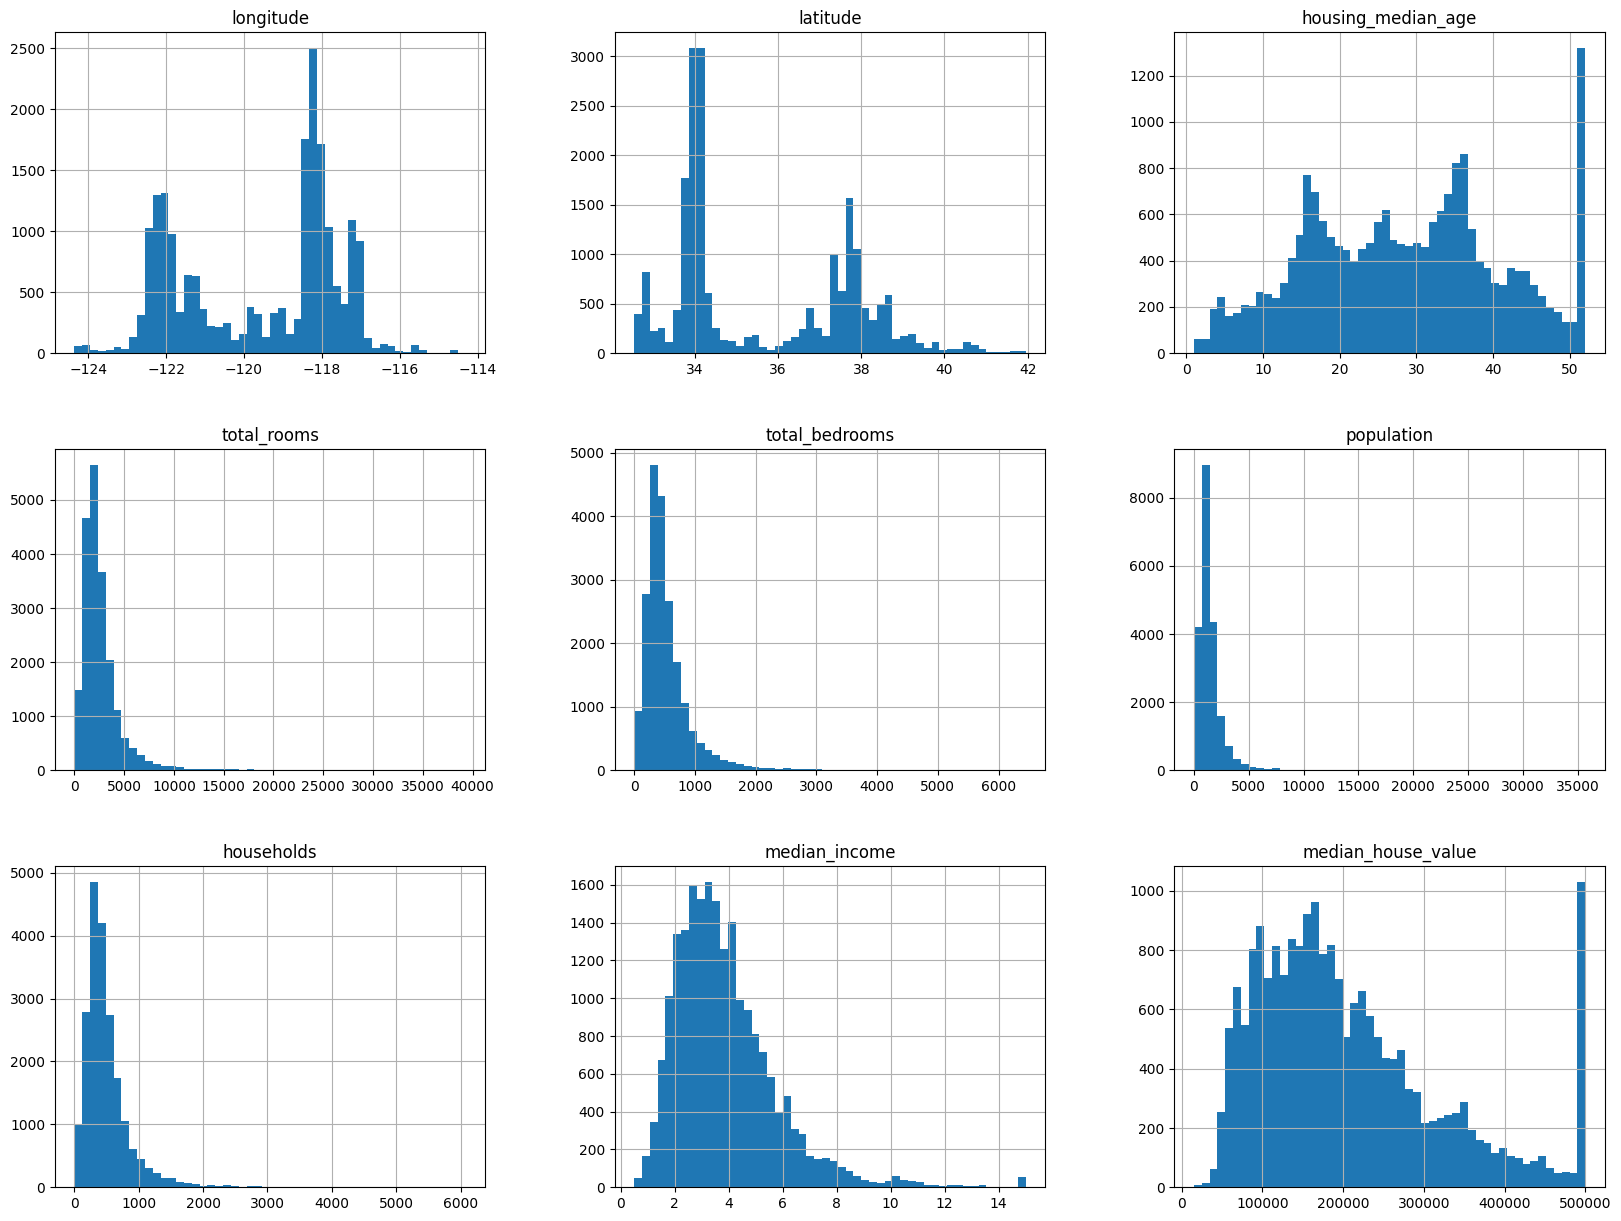

In [5]:
import matplotlib.pyplot as plt

# Plot histograms for all columns to see data distribution
df.hist(bins=50, figsize=(20, 15))

# Display the resulting charts
plt.show()

### Step 6: Splitting the Data
    I split the data into training and testing sets.
    This helps evaluate how well the model performs on unseen data.

In [6]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

# Verify the split sizes
print(f"Training set: {len(train_set)} rows")
print(f"Testing set: {len(test_set)} rows")

Training set: 16512 rows
Testing set: 4128 rows


### Step 7: Feature Scaling
    I applied scaling to make all features have similar ranges.
    This is important for models like Linear Regression.

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Create the scaler tool
scaler = StandardScaler()

# 2. Separate numerical data (drop the text column)
train_num = train_set.drop("ocean_proximity", axis=1)

# 3. Scale only the numerical data
train_set_scaled = scaler.fit_transform(train_num)

print("Scaling successful!")

Scaling successful!


### Step 8: Training the Model
     I trained a Linear Regression model.
     This model tries to find a linear relationship between features and house prices.

In [8]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model using the scaled training data
# We don't have the labels (prices) separated yet, so we will use the full scaled data for now
model.fit(train_set_scaled, train_set.drop("ocean_proximity", axis=1))

print("Model training complete!")

Model training complete!


### Step 9: Make Predictions and Evaluate
    I used the model to predict house prices on test data.
    Then I compared predicted values with actual values.

In [9]:
# 1. Prepare test data (drop the text column)
test_num = test_set.drop("ocean_proximity", axis=1)

# 2. Scale the test data using the SAME scaler as training
test_set_scaled = scaler.transform(test_num)

# 3. Make predictions on the test data
predictions = model.predict(test_set_scaled)

# 4. Show the first 5 predictions
print("First 5 Predictions:", predictions[:5])

First 5 Predictions: [[-1.19010e+02  3.60600e+01  2.50000e+01  1.50500e+03  4.35000e+02
   1.39200e+03  3.59000e+02  1.68120e+00  4.77000e+04]
 [-1.19460e+02  3.51400e+01  3.00000e+01  2.94300e+03  4.35000e+02
   1.56500e+03  5.84000e+02  2.53130e+00  4.58000e+04]
 [-1.22440e+02  3.78000e+01  5.20000e+01  3.83000e+03  4.35000e+02
   1.31000e+03  9.63000e+02  3.48010e+00  5.00001e+05]
 [-1.18720e+02  3.42800e+01  1.70000e+01  3.05100e+03  4.35000e+02
   1.70500e+03  4.95000e+02  5.73760e+00  2.18600e+05]
 [-1.21930e+02  3.66200e+01  3.40000e+01  2.35100e+03  4.35000e+02
   1.06300e+03  4.28000e+02  3.72500e+00  2.78000e+05]]


### Step 10: Evaluating Model Performance
    I evaluated the model using:
     - MAE
     - MSE
     - RMSE
     - R² score

    These metrics help measure how accurate the model is.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Define Features (X) and Target (y) for Training
y_train = train_set["median_house_value"]
X_train = train_set.drop(["median_house_value", "ocean_proximity"], axis=1)

# 2. Define Features (X) and Target (y) for Testing
y_test = test_set["median_house_value"]
X_test = test_set.drop(["median_house_value", "ocean_proximity"], axis=1)

# 3. Scale only the Features (X)
# (Ensure scaler is defined here or imported earlier)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Random Forest Model
forest_model = RandomForestRegressor(n_estimators=30, random_state=42)
forest_model.fit(X_train_scaled, y_train)

# 5. Predict and Calculate RMSE
predictions = forest_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"New Improved Random Forest RMSE: {rmse}")

New Improved Random Forest RMSE: 50413.243165611806


###     Model Improvement Insight
     
    Initially, the RMSE was very high (around 235,000), which showed that the model was not performing well.
    After handling missing values and applying feature scaling, the RMSE dropped significantly to around 50,000.
    This shows that proper data preprocessing plays a very important role in improving model performance.



### Conclusion
    Linear Regression provides a simple understanding of the relationship between features and house prices.
    However, house prices depend on complex and non-linear factors, which Linear Regression cannot fully capture.
    Random Forest performed better because it can model these non-linear relationships more effectively.

    Final Results:
       - Linear Regression RMSE: 235,228
       - Random Forest RMSE: 50,413

    Overall, Random Forest is a better choice for this problem.